In [32]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [34]:
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__) 

NumPy version: 2.5.2
Pandas version: 3.0.5
Scikit-learn version: 1.9.0


Loading IPL Dataset

In [65]:
df = pd.read_csv('ipl_matches_data_cleaned.csv')
df['match_date'] = pd.to_datetime(df['match_date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   match_id         1212 non-null   int64         
 1   season           1212 non-null   str           
 2   match_number     1142 non-null   float64       
 3   match_date       1212 non-null   datetime64[us]
 4   city             1161 non-null   str           
 5   venue            1212 non-null   str           
 6   team1            1212 non-null   str           
 7   team2            1212 non-null   str           
 8   toss_winner      1212 non-null   str           
 9   toss_decision    1212 non-null   str           
 10  result           1212 non-null   str           
 11  match_winner     1212 non-null   str           
 12  win_by_runs      546 non-null    float64       
 13  win_by_wickets   641 non-null    float64       
 14  player_of_match  1203 non-null   str           
dty

/var/folders/b2/mhjgs1354j705kfzvy4kq0vw0000gn/T/ipykernel_28217/438713445.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['match_date'] = pd.to_datetime(df['match_date'])


Analysing IPL Dataset

In [36]:
df.head(30)

,match_id,season,match_number,match_date,city,venue,team1,team2,toss_winner,toss_decision,result,match_winner,win_by_runs,win_by_wickets,player_of_match
0,335982,2008,1.0,18/04/2008,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,win,Kolkata Knight Riders,140.0,NaN,Brendon Barrie McCullum
1,1082591,2017,1.0,05/04/2017,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,win,Sunrisers Hyderabad,35.0,NaN,Yuvraj Singh
2,1082592,2017,2.0,06/04/2017,Pune,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,win,Rising Pune Supergiant,NaN,7.0,Steven Peter Devereux Smith
3,1082593,2017,3.0,07/04/2017,Rajkot,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,win,Kolkata Knight Riders,NaN,10.0,Christopher Austin Lynn
4,1082594,2017,4.0,08/04/2017,Indore,Holkar Cricket Stadium,Punjab Kings,Rising Pune Supergiant,Punjab Kings,field,win,Punjab Kings,NaN,6.0,Glenn James Maxwell
5,1082595,2017,5.0,08/04/2017,Bengaluru,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,win,Royal Challengers Bangalore,15.0,NaN,Kedar Mahadav Jadhav
6,1082596,2017,6.0,09/04/2017,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Gujarat Lions,Sunrisers Hyderabad,field,win,Sunrisers Hyderabad,NaN,9.0,Rashid Khan Arman
7,1082597,2017,7.0,09/04/2017,Mumbai,Wankhede Stadium,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians,field,win,Mumbai Indians,NaN,4.0,Nitish Rana
8,1082598,2017,8.0,10/04/2017,Indore,Holkar Cricket Stadium,Punjab Kings,Royal Challengers Bangalore,Royal Challengers Bangalore,bat,win,Punjab Kings,NaN,8.0,Axar Rajeshbhai Patel
9,1082599,2017,9.0,11/04/2017,Pune,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Delhi Capitals,Rising Pune Supergiant,field,win,Delhi Capitals,97.0,NaN,Sanju Viswanath Samson


In [37]:
df[df.isnull().values]

,match_id,season,match_number,match_date,city,venue,team1,team2,toss_winner,toss_decision,result,match_winner,win_by_runs,win_by_wickets,player_of_match
0,335982,2008,1.0,18/04/2008,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,win,Kolkata Knight Riders,140.0,NaN,Brendon Barrie McCullum
1,1082591,2017,1.0,05/04/2017,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,win,Sunrisers Hyderabad,35.0,NaN,Yuvraj Singh
2,1082592,2017,2.0,06/04/2017,Pune,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,win,Rising Pune Supergiant,NaN,7.0,Steven Peter Devereux Smith
3,1082593,2017,3.0,07/04/2017,Rajkot,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,win,Kolkata Knight Riders,NaN,10.0,Christopher Austin Lynn
4,1082594,2017,4.0,08/04/2017,Indore,Holkar Cricket Stadium,Punjab Kings,Rising Pune Supergiant,Punjab Kings,field,win,Punjab Kings,NaN,6.0,Glenn James Maxwell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1207,1529282,2026,39.0,27/04/2026,Delhi,"Arun Jaitley Stadium, Delhi",Delhi Capitals,Royal Challengers Bangalore,Royal Challengers Bangalore,field,win,Royal Challengers Bangalore,NaN,9.0,Josh Reginald Hazlewood
1208,1529283,2026,40.0,28/04/2026,New Chandigarh,Maharaja Yadavindra Singh International Cricke...,Punjab Kings,Rajasthan Royals,Rajasthan Royals,field,win,Rajasthan Royals,NaN,6.0,Donovan Ferreira
1209,1529284,2026,41.0,29/04/2026,Mumbai,"Wankhede Stadium, Mumbai",Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians,bat,win,Sunrisers Hyderabad,NaN,6.0,Heinrich Klaasen
1210,1529285,2026,42.0,30/04/2026,Ahmedabad,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bangalore,Gujarat Titans,Gujarat Titans,field,win,Gujarat Titans,NaN,4.0,Jason Omar Holder


In [38]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
match_id,1212.0,961685.974422,390532.810455,335982.0,548362.75,1082620.5,1304079.25,1529286.0
match_number,1142.0,31.328371,18.397497,1.0,16.00,31.0,46.00,72.0
win_by_runs,546.0,30.608059,27.010366,1.0,11.00,22.0,42.00,146.0
win_by_wickets,641.0,6.182527,1.837816,1.0,5.00,6.0,7.00,10.0


The data shows us that the average victory margin by runs is 30.6 and the average victory margin by wickets is 6.18.  
There is a standard deviation of 27runs in the victory margins batting first 
So 68% of the games won by thr team batting first are won between 3 and 57 runs. This is a slightly larger range than I expected. 

In [40]:
df.isnull().sum()

match_id             0
season               0
match_number        70
match_date           0
city                51
venue                0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
match_winner         0
win_by_runs        666
win_by_wickets     571
player_of_match      9
dtype: int64

Visualising Data Features

In [42]:
categorical_features = ["team 1", "team 2", "toss_winner", "toss_decision", "match_winner", "venue"]

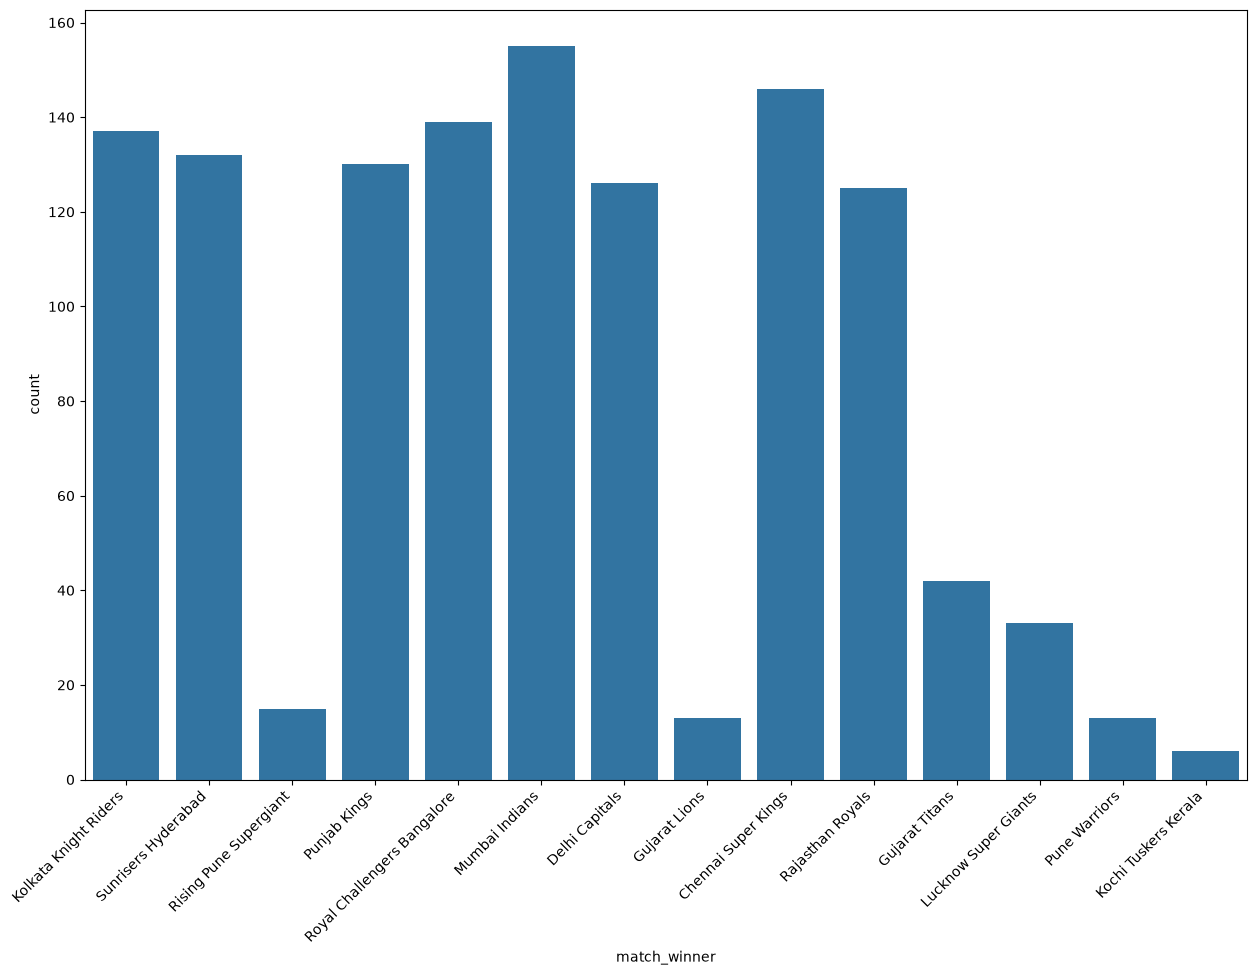

In [43]:
plt.subplots(figsize=(15, 10))
sns.countplot(x='match_winner', data=df)
plt.xticks(rotation=45, ha='right')  # Rotate labels by 45 degrees and align them
plt.show()

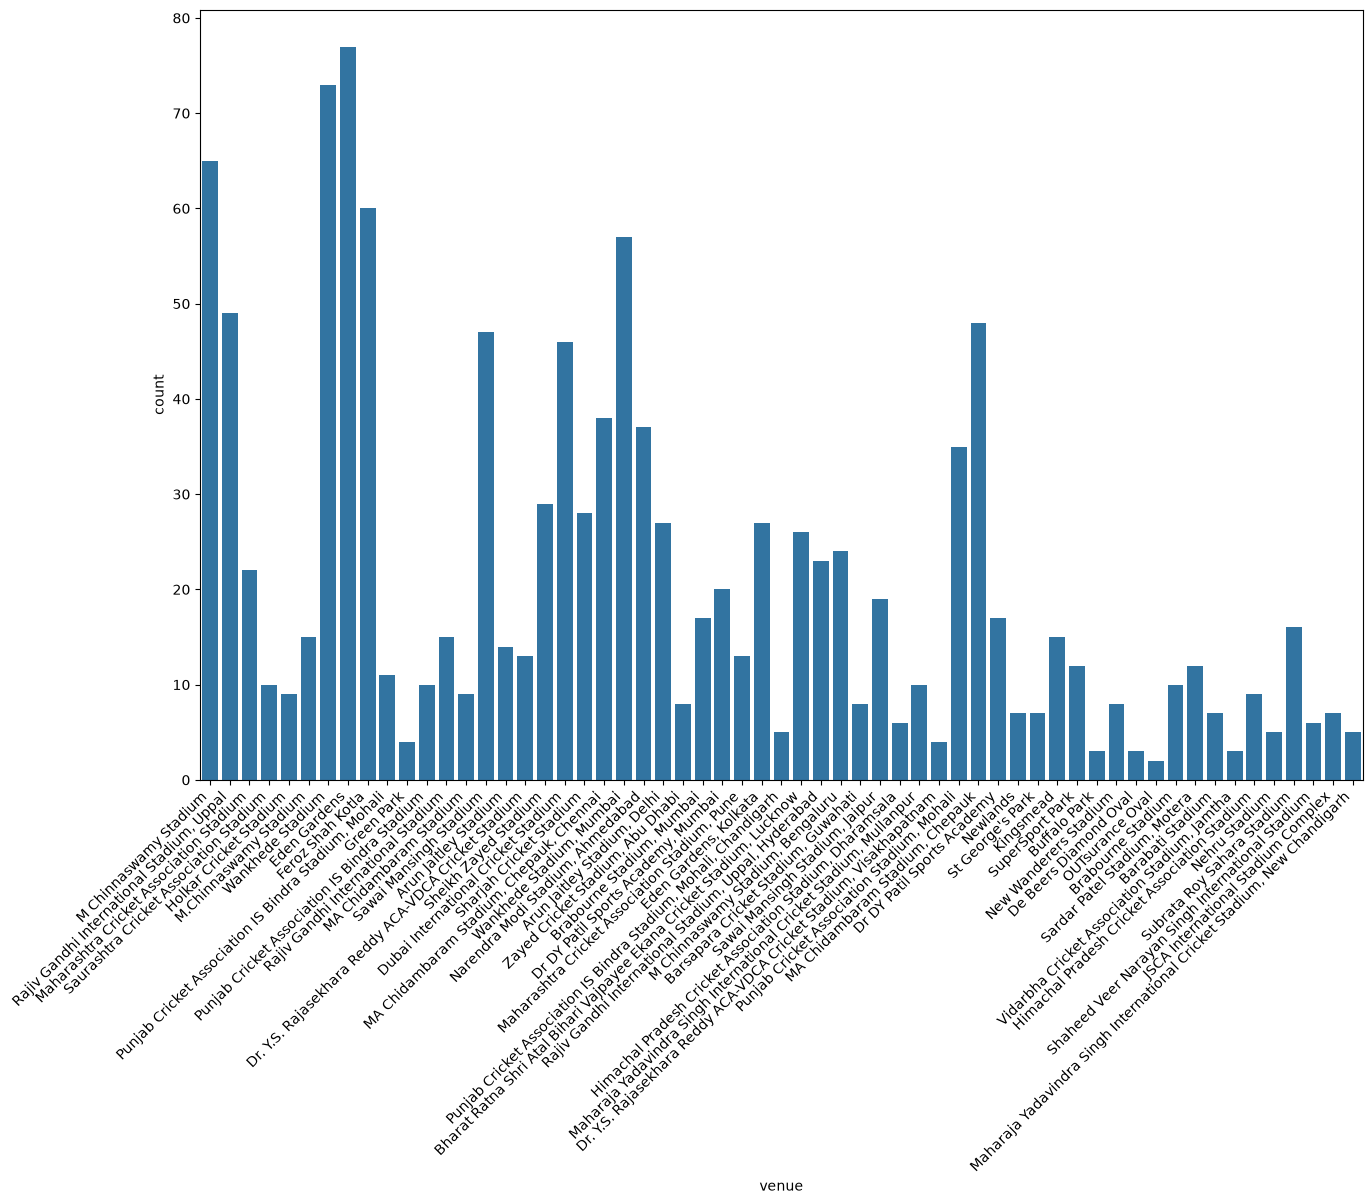

In [44]:
plt.subplots(figsize=(15, 10))
sns.countplot(x='venue', data=df)
plt.xticks(rotation=45, ha='right')  # Rotate labels by 45 degrees and align them
plt.show()

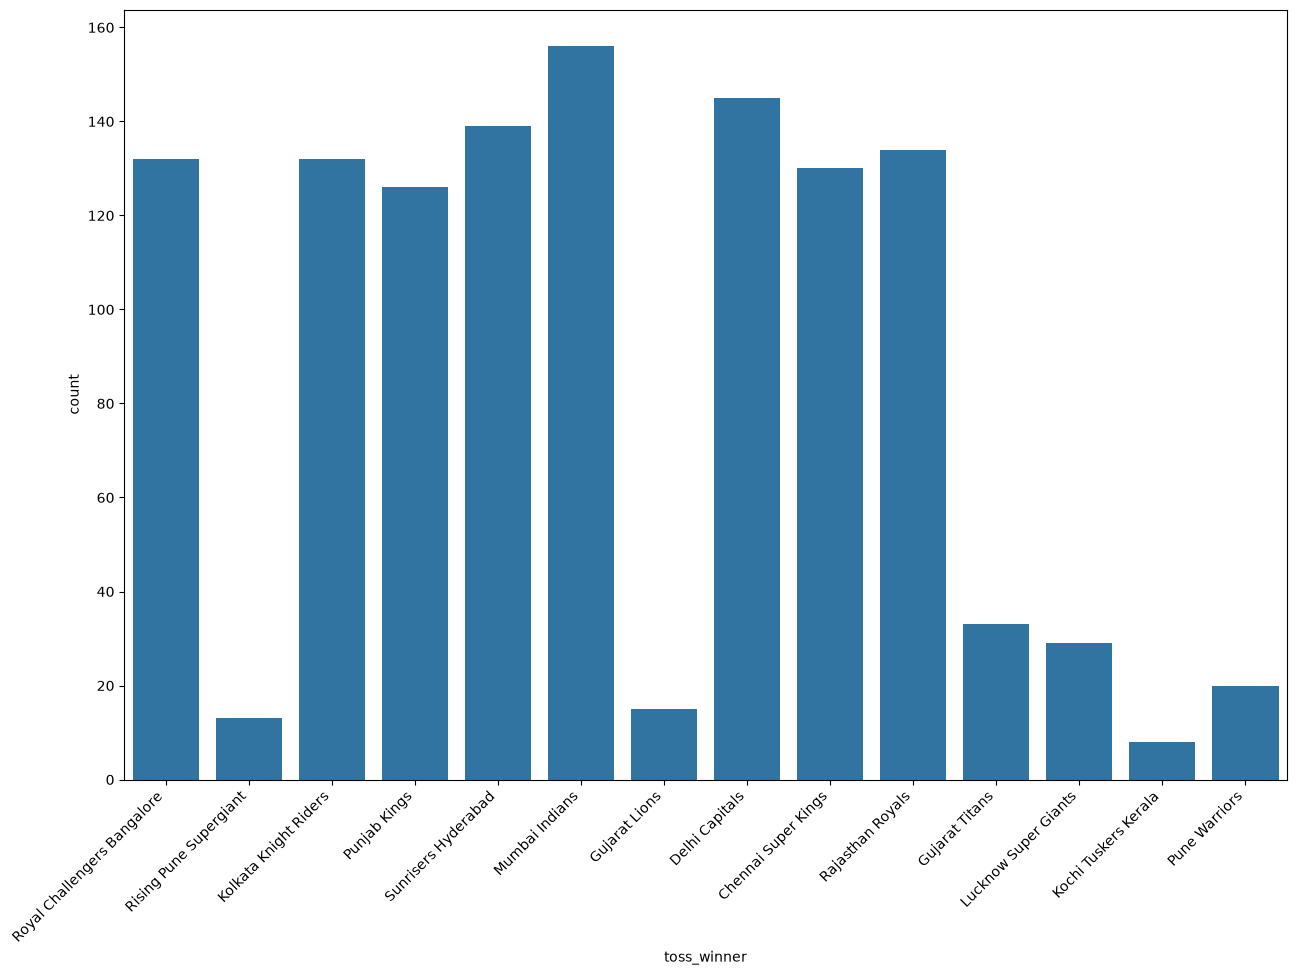

In [45]:
plt.subplots(figsize=(15, 10))
sns.countplot(x='toss_winner', data=df)
plt.xticks(rotation=45, ha='right')  # Rotate labels by 45 degrees and align them
plt.show()

In [48]:
# function to fetch total number of matches played by a team
def total_matches_played(team_name):
    matches_played = df[(df['team1'] == team_name) | (df['team2'] == team_name)]
    return len(matches_played)

def total_matches_won(team_name):
    matches_won = df[(df['match_winner'] == team_name)]
    return len(matches_won)

In [51]:
test = total_matches_played("Chennai Super Kings")
print(test)
wonny = total_matches_won("Chennai Super Kings")
print(wonny)

260
146


Identifying Features

In [ ]:
#Win percentage of each team

for team in df['match_winner'].unique():
    matches_played = total_matches_played(team)
    matches_won = total_matches_won(team)
    win_percentage = (matches_won / matches_played) * 100
    print(f"{team} has won {matches_won} matches out of {matches_played} matches played, with a win percentage of {win_percentage:.2f}%")


Kolkata Knight Riders has won 137 matches out of 272 matches played, with a win percentage of 50.37%
Sunrisers Hyderabad has won 132 matches out of 280 matches played, with a win percentage of 47.14%
Rising Pune Supergiant has won 15 matches out of 30 matches played, with a win percentage of 50.00%
Punjab Kings has won 130 matches out of 272 matches played, with a win percentage of 47.79%
Royal Challengers Bangalore has won 139 matches out of 279 matches played, with a win percentage of 49.82%
Mumbai Indians has won 155 matches out of 285 matches played, with a win percentage of 54.39%
Delhi Capitals has won 126 matches out of 276 matches played, with a win percentage of 45.65%
Gujarat Lions has won 13 matches out of 30 matches played, with a win percentage of 43.33%
Chennai Super Kings has won 146 matches out of 260 matches played, with a win percentage of 56.15%
Rajasthan Royals has won 125 matches out of 245 matches played, with a win percentage of 51.02%
Gujarat Titans has won 42 m

In [181]:
# function to fetch total number of matches played by a team


def total_matches_played_until_a_point(team_name,match_date):
    df_filtered = df[df['match_date'] < match_date]
    matches_played = df_filtered[(df_filtered['team1'] == team_name) | (df_filtered['team2'] == team_name)]
    return len(matches_played)

def total_matches_won_until_a_point(team_name,match_date):
    df_filtered = df[df['match_date'] < match_date]
    matches_won = df_filtered[(df_filtered  ['match_winner'] == team_name)]
    return len(matches_won)

test= total_matches_played_until_a_point("Royal Challengers Bangalore",pd.to_datetime("03/04/2017"))
print(test)
wonny = total_matches_won_until_a_point("Royal Challengers Bangalore",pd.to_datetime("03/04/2017"))
print(wonny)

139
70


In [217]:
def win_percentage_at_a_point(team_name, match_date):
    matches_played = total_matches_played_until_a_point(team_name, match_date)
    matches_won = total_matches_won_until_a_point(team_name, match_date)
    
    if matches_played == 0:
        return 0.0  # Avoid division by zero
    
    win_percentage = (matches_won / matches_played) * 100
    return win_percentage

test= win_percentage_at_a_point("Royal Challengers Bangalore", pd.to_datetime("2016-03-04"))
print(test)

49.59349593495935


In [183]:
def ratio_of_win_percentage(team1_win_percentage, team2_win_percentage):
    return team1_win_percentage / team2_win_percentage 


In [218]:
df['team1_win_percentage'] = df.apply(
    lambda row: max(win_percentage_at_a_point(row['team1'], row['match_date']), 10),
    axis=1
)
df['team2_win_percentage'] = df.apply(
    lambda row: max(win_percentage_at_a_point(row['team2'], row['match_date']), 10),
    axis=1
)

In [220]:
df["ratio_of_win_percentage"] = df.apply(
    lambda row: ratio_of_win_percentage(row['team1_win_percentage'], row['team2_win_percentage']),
    axis=1)

In [221]:
df.head()

,match_id,season,match_number,match_date,city,venue,team1,team2,toss_winner,toss_decision,result,match_winner,win_by_runs,win_by_wickets,player_of_match,team1_win_percentage,team2_win_percentage,binary_outcome,baseline,ratio_of_win_percentage
0,335982,2008,1.0,2008-04-18,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,win,Kolkata Knight Riders,140.0,NaN,Brendon Barrie McCullum,10.000000,10.000000,0,0.491749,1.000000
1,1082591,2017,1.0,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,win,Sunrisers Hyderabad,35.0,NaN,Yuvraj Singh,45.255474,50.359712,1,0.491749,0.898644
2,1082592,2017,2.0,2017-04-06,Pune,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,win,Rising Pune Supergiant,NaN,7.0,Steven Peter Devereux Smith,35.714286,57.142857,1,0.491749,0.625000
3,1082593,2017,3.0,2017-04-07,Rajkot,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,win,Kolkata Knight Riders,NaN,10.0,Christopher Austin Lynn,56.250000,51.515152,0,0.491749,1.091912
4,1082594,2017,4.0,2017-04-08,Indore,Holkar Cricket Stadium,Punjab Kings,Rising Pune Supergiant,Punjab Kings,field,win,Punjab Kings,NaN,6.0,Glenn James Maxwell,47.014925,40.000000,1,0.491749,1.175373


In [222]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
match_id,1212.0,961685.974422,335982.0,548362.75,1082620.5,1304079.25,1529286.0,390532.810455
match_number,1142.0,31.328371,1.0,16.0,31.0,46.0,72.0,18.397497
match_date,1212,2017-05-15 07:12:28.514851,2008-04-18 00:00:00,2012-05-11 18:00:00,2017-04-26 12:00:00,2022-04-21 06:00:00,2026-05-01 00:00:00,NaN
win_by_runs,546.0,30.608059,1.0,11.0,22.0,42.0,146.0,27.010366
win_by_wickets,641.0,6.182527,1.0,5.0,6.0,7.0,10.0,1.837816
team1_win_percentage,1212.0,50.612708,10.0,46.413502,50.469991,56.605723,100.0,10.398391
team2_win_percentage,1212.0,51.030469,10.0,46.379976,50.678789,56.578947,100.0,10.701986
binary_outcome,1212.0,0.491749,0.0,0.0,0.0,1.0,1.0,0.500138
baseline,1212.0,0.491749,0.491749,0.491749,0.491749,0.491749,0.491749,0.0
ratio_of_win_percentage,1212.0,1.064143,0.1,0.862043,0.994643,1.148223,10.0,0.625005


Establishing baseline AUC

In [223]:
df["binary_outcome"] = df.apply(lambda row: 1 if row['match_winner'] == row['team1'] else 0, axis=1)
perce = df["binary_outcome"].sum()
df["baseline"] = perce / len(df)
df.head()

,match_id,season,match_number,match_date,city,venue,team1,team2,toss_winner,toss_decision,result,match_winner,win_by_runs,win_by_wickets,player_of_match,team1_win_percentage,team2_win_percentage,binary_outcome,baseline,ratio_of_win_percentage
0,335982,2008,1.0,2008-04-18,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,win,Kolkata Knight Riders,140.0,NaN,Brendon Barrie McCullum,10.000000,10.000000,0,0.491749,1.000000
1,1082591,2017,1.0,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,win,Sunrisers Hyderabad,35.0,NaN,Yuvraj Singh,45.255474,50.359712,1,0.491749,0.898644
2,1082592,2017,2.0,2017-04-06,Pune,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,win,Rising Pune Supergiant,NaN,7.0,Steven Peter Devereux Smith,35.714286,57.142857,1,0.491749,0.625000
3,1082593,2017,3.0,2017-04-07,Rajkot,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,win,Kolkata Knight Riders,NaN,10.0,Christopher Austin Lynn,56.250000,51.515152,0,0.491749,1.091912
4,1082594,2017,4.0,2017-04-08,Indore,Holkar Cricket Stadium,Punjab Kings,Rising Pune Supergiant,Punjab Kings,field,win,Punjab Kings,NaN,6.0,Glenn James Maxwell,47.014925,40.000000,1,0.491749,1.175373


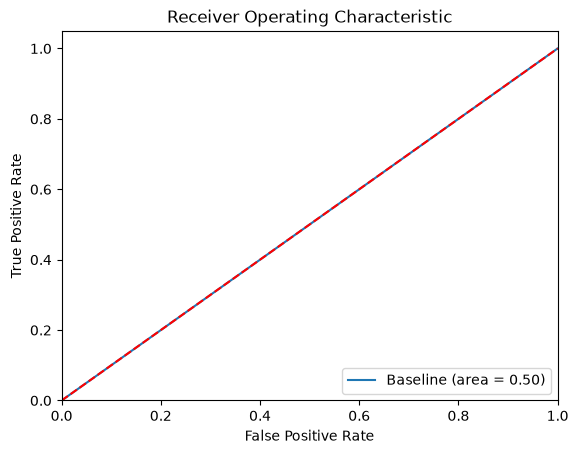

In [224]:
#AUC ROC Curve
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

logit_roc_auc = roc_auc_score(df['binary_outcome'], df['baseline'])
fpr, tpr, thresholds = roc_curve(df['binary_outcome'], df['baseline'])
plt.figure
plt.plot(fpr, tpr, label='Baseline (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")       
plt.savefig('Log_ROC')
plt.show()

In [225]:
auc_score = roc_auc_score(df['binary_outcome'], df['baseline'])
rounded_auc_score = round(auc_score, 2)
print("AUC Score:", rounded_auc_score)


AUC Score: 0.5


Preparing data for first basic model training


In [226]:
team1_win_rate_data = df[['team1_win_percentage', 'binary_outcome']].copy()
team1_win_rate_data.head()
team1_win_rate_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   team1_win_percentage  1212 non-null   float64
 1   binary_outcome        1212 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 19.1 KB


In [227]:
team1_win_rate_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
team1_win_percentage,1212.0,50.612708,10.398391,10.0,46.413502,50.469991,56.605723,100.0
binary_outcome,1212.0,0.491749,0.500138,0.0,0.000000,0.000000,1.000000,1.0


In [228]:
X = team1_win_rate_data[['team1_win_percentage']]
Y = team1_win_rate_data['binary_outcome']

Building the First Model

In [229]:
# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Calculate the proportion of positive and negative samples in the training set whether it is the same as the original dataset
Y_train.info()
proportion_positive = Y_train.mean()
proportion_negative = 1 - proportion_positive
print("Proportion of positive samples in training set:", proportion_positive)
print("Proportion of negative samples in training set:", proportion_negative)

# Calculate the proportion of positive and negative samples in the test set whether it is the same as the original dataset
Y_test.info()
proportion_positive = Y_test.mean()
proportion_negative = 1 - proportion_positive
print("Proportion of positive samples in test set:", proportion_positive)
print("Proportion of negative samples in test set:", proportion_negative)

                                                    

<class 'pandas.Series'>
Index: 969 entries, 806 to 1126
Series name: binary_outcome
Non-Null Count  Dtype
--------------  -----
969 non-null    int64
dtypes: int64(1)
memory usage: 15.1 KB
Proportion of positive samples in training set: 0.49742002063983487
Proportion of negative samples in training set: 0.5025799793601651
<class 'pandas.Series'>
Index: 243 entries, 801 to 464
Series name: binary_outcome
Non-Null Count  Dtype
--------------  -----
243 non-null    int64
dtypes: int64(1)
memory usage: 3.8 KB
Proportion of positive samples in test set: 0.4691358024691358
Proportion of negative samples in test set: 0.5308641975308642


In [145]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [230]:
import statsmodels.api as sm

logit_model = sm.Logit(Y_train, sm.add_constant(X_train))
logit_result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.690773
         Iterations 4


In [231]:
# Summary of the logistic regression model
logit_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         binary_outcome   No. Observations:                  969
Model:                          Logit   Df Residuals:                      967
Method:                           MLE   Df Model:                            1
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                0.003406
Time:                        21:46:40   Log-Likelihood:                -669.36
converged:                       True   LL-Null:                       -671.65
Covariance Type:            nonrobust   LLR p-value:                   0.03244
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.7237      0.343     -2.109      0.035      -1.396      -0.051
team1_win_percentage     0.0141      0.007      2.116      0.034       0.001       0.027
========================================================================================
"""

In [232]:
X_train.info()
predictions_training = logit_result.predict(sm.add_constant(X_train))

# Convert probabilities to binary class predictions (0 or 1) using a 0.5 threshold
#prediction_binary_outcomes = (predictions_training >= 0.5).astype(int)


<class 'pandas.DataFrame'>
Index: 969 entries, 806 to 1126
Data columns (total 1 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   team1_win_percentage  969 non-null    float64
dtypes: float64(1)
memory usage: 15.1 KB


In [233]:
predictions_training.head(10)

806     0.489265
591     0.514268
361     0.525430
266     0.530992
879     0.490250
1134    0.515018
1161    0.481749
1189    0.481347
991     0.494753
575     0.494753
dtype: float64

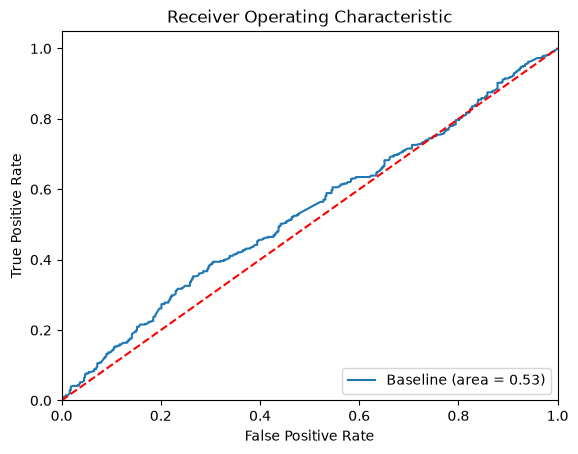

In [234]:

# Plotting the ROC curve for the logistic regression model for the Training Data Set
logit_roc_auc = roc_auc_score(Y_train, predictions_training)
fpr, tpr, thresholds = roc_curve(Y_train, predictions_training)
plt.figure
plt.plot(fpr, tpr, label='Baseline (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")       
plt.savefig('Log_ROC')
plt.show()


In [235]:
auc_score = roc_auc_score(Y_train, predictions_training)
rounded_auc_score = round(auc_score, 2)
print("AUC Score:", rounded_auc_score)

AUC Score: 0.53


In [236]:
X_test.info()
predictions_test = logit_result.predict(sm.add_constant(X_test))
predictions_test.head(10)

<class 'pandas.DataFrame'>
Index: 243 entries, 801 to 464
Data columns (total 1 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   team1_win_percentage  243 non-null    float64
dtypes: float64(1)
memory usage: 3.8 KB


801    0.500420
677    0.508265
43     0.481616
990    0.518484
70     0.509391
704    0.515175
908    0.513350
210    0.500420
599    0.525731
306    0.529851
dtype: float64

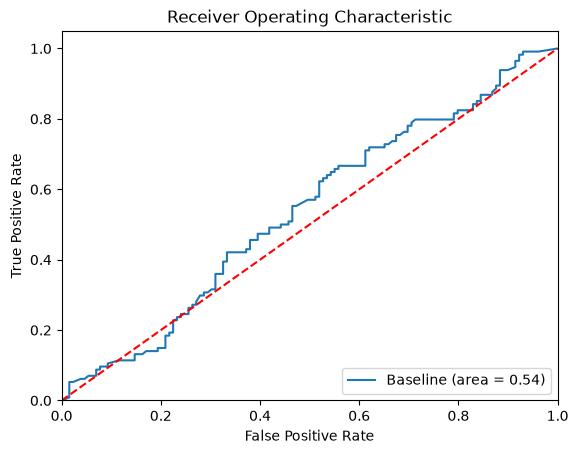

In [237]:
# Plotting the ROC curve for the logistic regression model for the Test Data Set
logit_roc_auc = roc_auc_score(Y_test, predictions_test)
fpr, tpr, thresholds = roc_curve(Y_test, predictions_test)
plt.figure
plt.plot(fpr, tpr, label='Baseline (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")       
plt.savefig('Log_ROC')
plt.show()


Building the second model after adding more features

In [238]:
team12_win_rate_data = df[['team1_win_percentage',"team2_win_percentage", 'binary_outcome']].copy()
team12_win_rate_data.head(15)
#team12_win_rate_data.info()

,team1_win_percentage,team2_win_percentage,binary_outcome
0,10.000000,10.000000,0
1,45.255474,50.359712,1
2,35.714286,57.142857,1
3,56.250000,51.515152,0
4,47.014925,40.000000,1
5,50.000000,43.609023,1
6,45.652174,52.941176,1
7,56.737589,51.879699,1
8,47.407407,50.354610,1
9,37.500000,43.283582,0


In [239]:
X = team12_win_rate_data[['team1_win_percentage',"team2_win_percentage"]]
Y = team12_win_rate_data['binary_outcome']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Calculate the proportion of positive and negative samples in the training set whether it is the same as the original dataset
Y_train.info()
proportion_positive = Y_train.mean()
proportion_negative = 1 - proportion_positive
print("Proportion of positive samples in training set:", proportion_positive)
print("Proportion of negative samples in training set:", proportion_negative)

# Calculate the proportion of positive and negative samples in the test set whether it is the same as the original dataset
Y_test.info()
proportion_positive = Y_test.mean()
proportion_negative = 1 - proportion_positive
print("Proportion of positive samples in test set:", proportion_positive)
print("Proportion of negative samples in test set:", proportion_negative)



<class 'pandas.Series'>
Index: 969 entries, 806 to 1126
Series name: binary_outcome
Non-Null Count  Dtype
--------------  -----
969 non-null    int64
dtypes: int64(1)
memory usage: 15.1 KB
Proportion of positive samples in training set: 0.49742002063983487
Proportion of negative samples in training set: 0.5025799793601651
<class 'pandas.Series'>
Index: 243 entries, 801 to 464
Series name: binary_outcome
Non-Null Count  Dtype
--------------  -----
243 non-null    int64
dtypes: int64(1)
memory usage: 3.8 KB
Proportion of positive samples in test set: 0.4691358024691358
Proportion of negative samples in test set: 0.5308641975308642


In [240]:
# training the logistic regression model with two features: team1_win_percentage and team2_win_percentage
logit_model = sm.Logit(Y_train, sm.add_constant(X_train))
logit_result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.689985
         Iterations 4


In [241]:
logit_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         binary_outcome   No. Observations:                  969
Model:                          Logit   Df Residuals:                      966
Method:                           MLE   Df Model:                            2
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                0.004542
Time:                        21:48:20   Log-Likelihood:                -668.60
converged:                       True   LL-Null:                       -671.65
Covariance Type:            nonrobust   LLR p-value:                   0.04732
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.3270      0.468     -0.699      0.485      -1.244       0.590
team1_win_percentage     0.0141      0.007      2.119      0.034       0.001       0.027
team2_win_percentage    -0.0078      0.006     -1.232      0.218      -0.020       0.005
========================================================================================
"""

In [242]:
predictions_test = logit_result.predict(sm.add_constant(X_test))
predictions_test.head(10)

801    0.521877
677    0.501853
43     0.487411
990    0.515905
70     0.515153
704    0.510339
908    0.493271
210    0.508592
599    0.481500
306    0.608285
dtype: float64

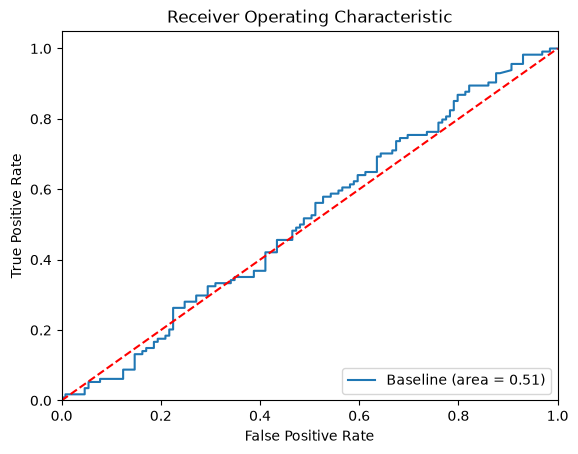

In [243]:
logit_roc_auc = roc_auc_score(Y_test, predictions_test)
fpr, tpr, thresholds = roc_curve(Y_test, predictions_test)
plt.figure
plt.plot(fpr, tpr, label='Baseline (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")       
plt.savefig('Log_ROC')
plt.show()


Creating a new model with more predictive feature using ratio of win predictor

In [244]:
ratio_win_rate_data = df[["ratio_of_win_percentage", 'binary_outcome']].copy()
ratio_win_rate_data.head()


,ratio_of_win_percentage,binary_outcome
0,1.000000,0
1,0.898644,1
2,0.625000,1
3,1.091912,0
4,1.175373,1


In [245]:
X = ratio_win_rate_data["ratio_of_win_percentage"]
Y = team1_win_rate_data['binary_outcome']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Calculate the proportion of positive and negative samples in the training set whether it is the same as the original dataset
Y_train.info()
proportion_positive = Y_train.mean()
proportion_negative = 1 - proportion_positive
print("Proportion of positive samples in training set:", proportion_positive)
print("Proportion of negative samples in training set:", proportion_negative)

# Calculate the proportion of positive and negative samples in the test set whether it is the same as the original dataset
Y_test.info()
proportion_positive = Y_test.mean()
proportion_negative = 1 - proportion_positive
print("Proportion of positive samples in test set:", proportion_positive)
print("Proportion of negative samples in test set:", proportion_negative)


<class 'pandas.Series'>
Index: 969 entries, 806 to 1126
Series name: binary_outcome
Non-Null Count  Dtype
--------------  -----
969 non-null    int64
dtypes: int64(1)
memory usage: 15.1 KB
Proportion of positive samples in training set: 0.49742002063983487
Proportion of negative samples in training set: 0.5025799793601651
<class 'pandas.Series'>
Index: 243 entries, 801 to 464
Series name: binary_outcome
Non-Null Count  Dtype
--------------  -----
243 non-null    int64
dtypes: int64(1)
memory usage: 3.8 KB
Proportion of positive samples in test set: 0.4691358024691358
Proportion of negative samples in test set: 0.5308641975308642


In [246]:
logit_model = sm.Logit(Y_train, sm.add_constant(X_train))
logit_result = logit_model.fit()


Optimization terminated successfully.
         Current function value: 0.691578
         Iterations 5


In [247]:
logit_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         binary_outcome   No. Observations:                  969
Model:                          Logit   Df Residuals:                      967
Method:                           MLE   Df Model:                            1
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                0.002245
Time:                        21:49:26   Log-Likelihood:                -670.14
converged:                       True   LL-Null:                       -671.65
Covariance Type:            nonrobust   LLR p-value:                   0.08246
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.2173      0.146     -1.493      0.135      -0.503       0.068
ratio_of_win_percentage     0.1954      0.124      1.570      0.116      -0.048       0.439
===========================================================================================
"""

In [248]:
predictions_test = logit_result.predict(sm.add_constant(X_test))
predictions_test.head(10)

801    0.508699
677    0.494122
43     0.492746
990    0.498643
70     0.500734
704    0.496641
908    0.489740
210    0.499531
599    0.484670
306    0.722130
dtype: float64

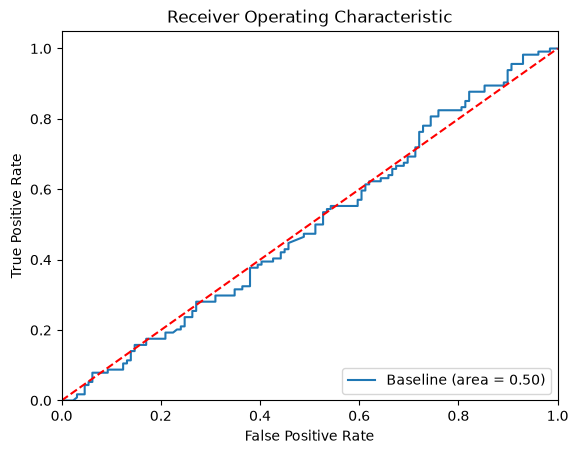

In [249]:
logit_roc_auc = roc_auc_score(Y_test, predictions_test)
fpr, tpr, thresholds = roc_curve(Y_test, predictions_test)
plt.figure
plt.plot(fpr, tpr, label='Baseline (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")       
plt.savefig('Log_ROC')
plt.show()


In [250]:
ratio_win_rate_data.corr()

,ratio_of_win_percentage,binary_outcome
ratio_of_win_percentage,1.000000,0.032771
binary_outcome,0.032771,1.000000


So why arent our features imporivng the AUC?
Lets make the hypothesis explicit:
we expected the winrate ratio feature to work because we thought that the ratio (winrateTeam1/winrateTeam2) would be higher in the cases where team 1 wins compared to cases where team 2 wins.
H0: there is no statistically significant diffrence between mean ratio in the cases where team 1 wins vs mean ratio in the cases where team 2 wins
lets get hypothesis testing

In [251]:
team1_data=(df[["ratio_of_win_percentage"]][df['team1'] == df['match_winner']])
team2_data=(df[["ratio_of_win_percentage"]][df['team2'] == df['match_winner']])
team1_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ratio_of_win_percentage,596.0,1.084957,0.707905,0.204762,0.873861,1.001487,1.173012,10.0


In [252]:
team2_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ratio_of_win_percentage,616.0,1.044005,0.53248,0.1,0.845003,0.981702,1.126731,6.666667
